In [1]:
%load_ext autoreload
%autoreload 2

import hydra
from hydra.core.global_hydra import GlobalHydra

GlobalHydra.instance().clear()
hydra.initialize(version_base=None, config_path="../conf")
cfg = hydra.compose(config_name="config")

from modules.data_services.data_utils import load_dataframe

In [2]:
pair_selection_start = cfg.pair_selection.start
pair_selection_end = cfg.pair_selection.end

df = load_dataframe(file_name=f"pair_selection_{pair_selection_start}_{pair_selection_end}")

In [3]:
df.head(5)

,pair,ssd,corr_log_returns,eg_p_value
0,BNBUSDT-UNIUSDT,30.106199,0.356806,0.001301
1,ETHUSDT-BCHUSDT,35.760886,0.589011,0.005810
2,BTCUSDT-BCHUSDT,24.048188,0.633006,0.008340
3,BTCUSDT-ADAUSDT,49.567267,0.711226,0.013760
4,ETHUSDT-UNIUSDT,49.868910,0.399035,0.019243


In [4]:
# from modules.visualization.plots import plot_positions, plot_pnl, plot_zscore
# from modules.data_services.data_utils import load_strategy_result, load_btc_benchmark
#
# interval = cfg.market.interval
#
# opt_start = cfg.performance.optimization.start
# opt_end = cfg.performance.optimization.end
#
# for i in range(5):
#     ticker_x = df["pair"][i].split("-")[0]
#     ticker_y = df["pair"][i].split("-")[1]
#
#     result_opt = load_strategy_result(file_name=f"opt_{ticker_x}_{ticker_y}")
#
#     # plot_positions(result_opt, show=True)
#     btc_data = load_btc_benchmark(
#         test_start=opt_start,
#         test_end=opt_end,
#         interval=interval,
#     )
#     plot_pnl(result_opt, btc_data, show=True)
#     # plot_zscore(result_opt, show=True)

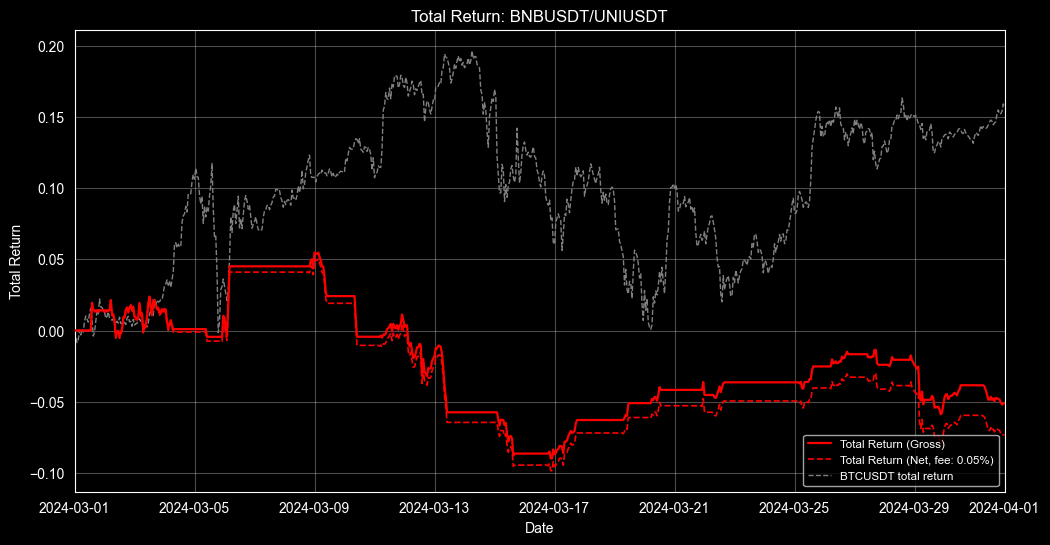

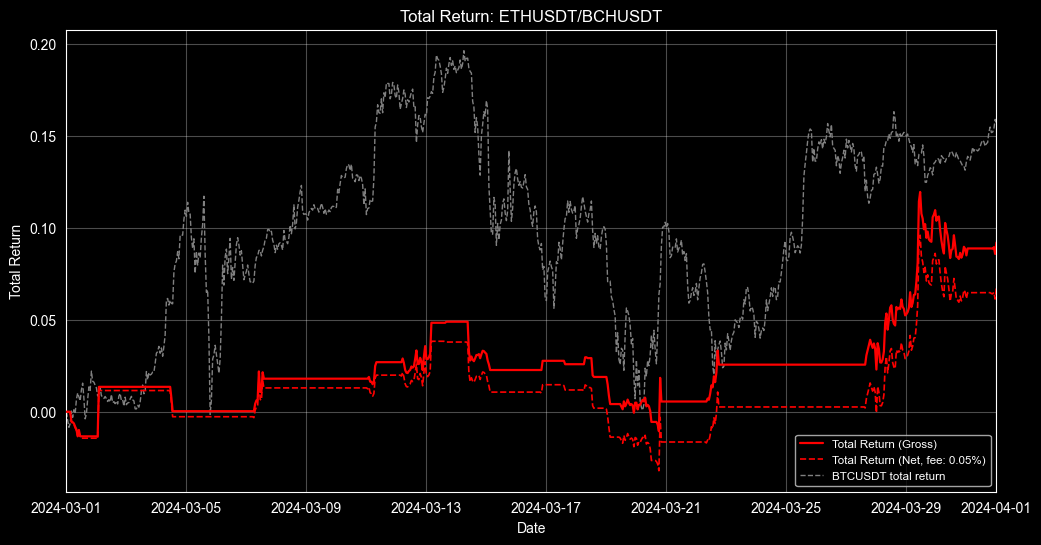

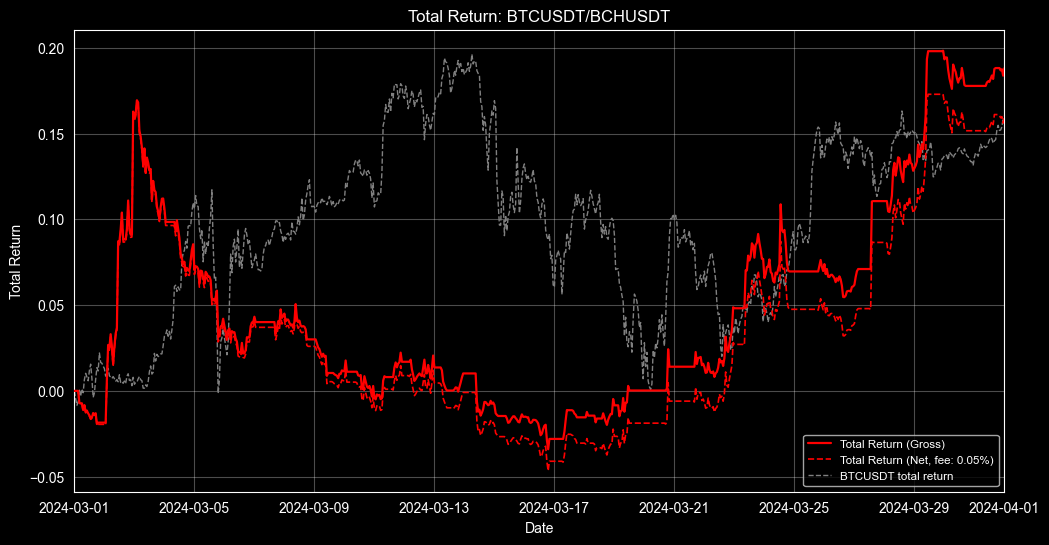

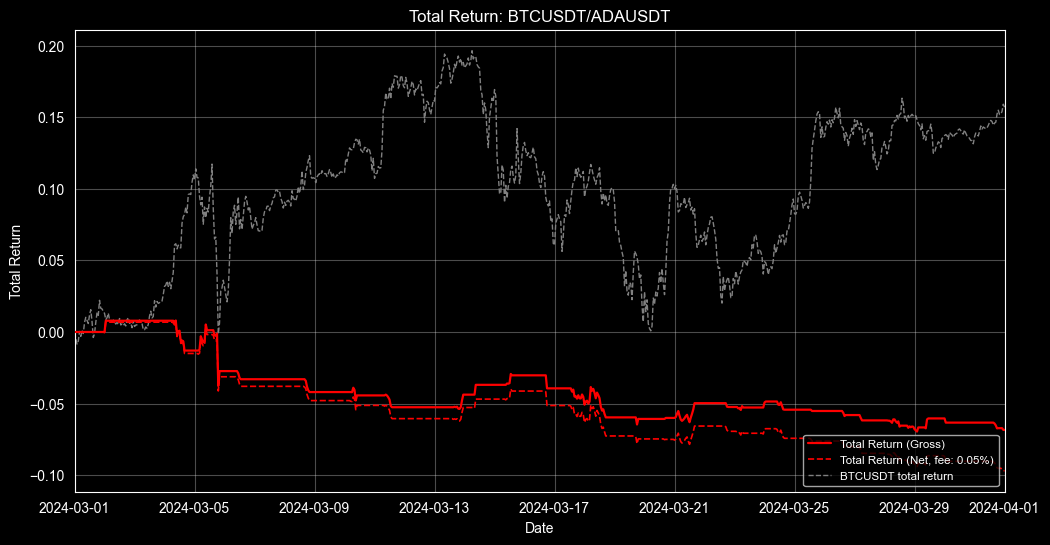

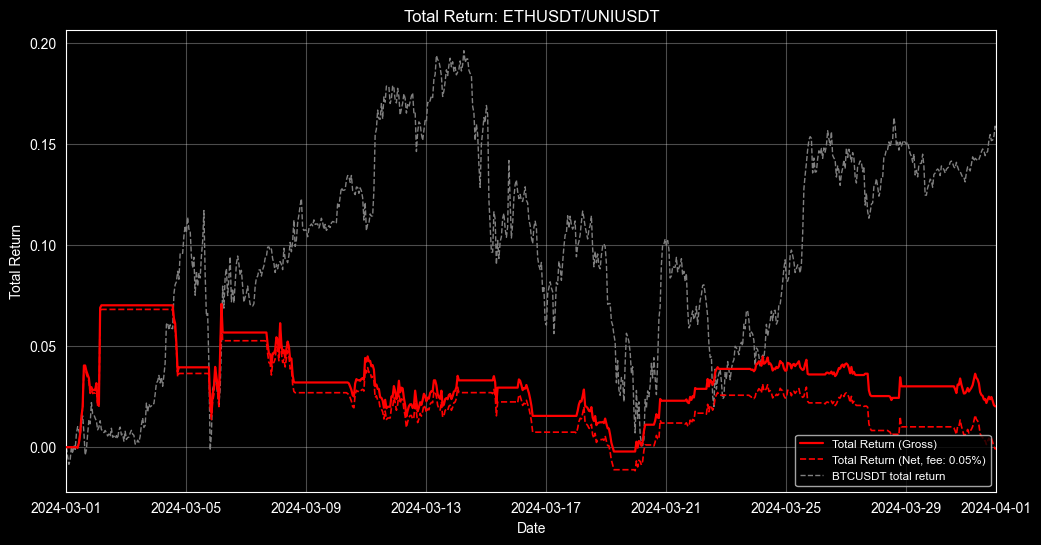

In [5]:
from modules.visualization.plots import plot_positions, plot_pnl, plot_zscore
from modules.data_services.data_utils import load_strategy_result, load_btc_benchmark

interval = cfg.market.interval

test_start = cfg.performance.test.start
test_end = cfg.performance.test.end

for i in range(5):
    ticker_x = df["pair"][i].split("-")[0]
    ticker_y = df["pair"][i].split("-")[1]

    # result_opt = load_strategy_result(file_name=f"opt_{ticker_x}_{ticker_y}")
    result_test = load_strategy_result(file_name=f"test_{ticker_x}_{ticker_y}")

    # plot_positions(result_test, show=True)
    btc_data = load_btc_benchmark(
        test_start=test_start,
        test_end=test_end,
        interval=interval,
    )
    plot_pnl(result_test, btc_data, show=True)
    # plot_zscore(result_test, show=True)

In [6]:
# TODO: MERGE
# opt + test dla każdej pary osobno (osobne wykresy, df'y i stats; załadowane parquety i parametry wyciągnięte z df'a (np. z pierwszego wiersza) i z pola rolling_window, przekazywane dalej do testu) oraz merge na końcu nową funkcją + stats nową funkcją dla multi-pair